In [5]:
%pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\ggsaw\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


# Analiza Chorób Serca - Regresja Logistyczna

Autor: Grzegorz Sawicki - 119156

Celem zadania jest analiza zbioru Heart Disease oraz budowa modelu klasyfikacji binarnej.


## 1. Ładowanie danych

W tej sekcji dokonano importu niezbędnych bibliotek oraz pobrania zbioru danych Heart Disease z repozytorium UCI przy użyciu biblioteki ucimlrepo.

Kluczowe obserwacje:

Struktura danych: Zmienna X zawiera cechy kliniczne pacjentów (np. wiek, ciśnienie krwi), natomiast y zawiera informację o występowaniu choroby.

Brakujące wartości: Analiza funkcją isnull().sum() wykazała braki w dwóch kolumnach:

ca (4 braki)

thal (2 braki)

Wnioski: Ze względu na to, że algorytmy scikit-learn nie obsługują brakujących danych, w kolejnym kroku konieczne będzie przeprowadzenie imputacji (uzupełnienia braków) oraz kodowania zmiennych kategorycznych, aby model mógł poprawnie przetworzyć dane.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

# Pobieranie danych
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

print("Braki w danych:")
print(X.isnull().sum())

Braki w danych:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


## 2. Przygotowanie danych

Ponieważ w poprzednim kroku wykryliśmy braki w kolumnach ca i thal, musimy je uzupełnić. Zastosujemy medianę, ponieważ jest ona odporna na wartości odstające.

In [15]:
X_clean = X.fillna(X.median())
print(X_clean.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


## 3. Analiza danych (EDA)
Celem tego etapu jest zrozumienie struktury zbioru danych oraz identyfikacja zależności między cechami. Skupimy się na:
* Analizie statystycznej: sprawdzeniu średnich, odchyleń i zakresów wartości.
* Weryfikacji braków: potwierdzeniu liczby pustych rekordów do późniejszego uzupełnienia.
* Rozkładzie zmiennej celu: sprawdzeniu, czy klasy (osoby zdrowe i chore) są zrównoważone liczebnie.

In [16]:
# wyświetlenie podstawowych statystyk 
print("Statystyki opisowe zbioru:")
display(X.describe())

# wyśiwetlanie info o typach danych
print("\nInformacje o strukturze danych:")
X.info()

Statystyki opisowe zbioru:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000



Informacje o strukturze danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


### Interpretacja statystyk:
* **Wiek (age):** Średni wiek badanych to ok. 54 lata (zakres 29-77), co sugeruje grupę podwyższonego ryzyka.
* **Cholesterol (chol):** Średnia wynosi 246 mg/dl, co przekracza normy medyczne (norma < 200). Wartość maksymalna (564 mg/dl) jest bardzo wysoka i może być silnym wskaźnikiem choroby.
* **Ciśnienie (trestbps):** Średnie ciśnienie spoczynkowe to 131 mmHg, jednak mamy pacjentów z wynikiem 200 mmHg.
* Płeć (sex): Średnia wynosi ok. 0.68, co oznacza, że w zbiorze przeważają mężczyźni (stanowią oni ok. 68% badanych). Jest to istotna informacja, gdyż płeć jest statystycznie znaczącym czynnikiem ryzyka chorób serca.

* **Tętno maksymalne (thalach):** Średnie osiągane tętno to 149 bpm, jednak rozpiętość jest bardzo duża — od 71 do aż 202 bpm. Wysokie tętno maksymalne zazwyczaj koreluje z lepszą wydolnością, a jego niskie wartości u pacjentów w starszym wieku mogą wskazywać na problemy kardiologiczne.

* **Obniżenie odcinka ST (oldpeak):** Średnia wartość to 1.04, ale maksymalna wynosi aż 6.2. W kardiologii wyższe wartości oldpeak (obniżenie odcinka ST wywołane wysiłkiem względem spoczynku) są silnym sygnałem niedokrwienia serca.

* **Liczba naczyń krwionośnych (ca):** Wiersz count potwierdza nasze wcześniejsze znalezisko — dla tej zmiennej mamy tylko 299 rekordów (zamiast 303), co oznacza 4 brakujące wartości wymagające uzupełnienia.

* **Wynik testu talowego (thal):** Tutaj również widzimy brak (301 rekordów zamiast 303). Średnia w okolicy 4.7 jest mało intuicyjna, ponieważ jest to zmienna kategoryczna (zakodowana liczbami 3, 6, 7), co potwierdza, że musimy ją traktować jako kategorię, a nie zwykłą liczbę.

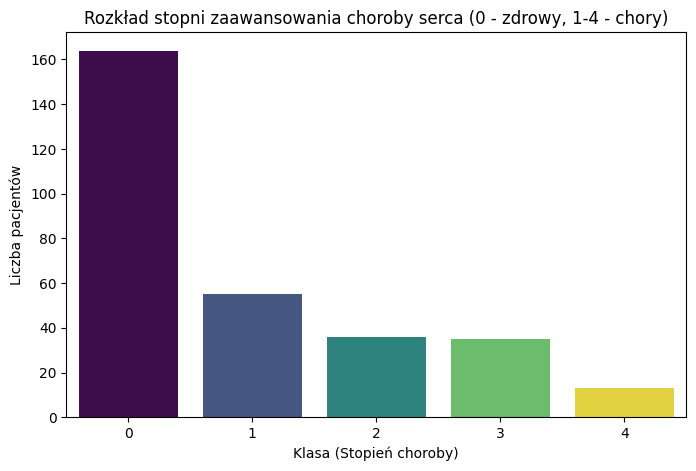

In [23]:
# Wykres liczebności klas w zmiennej celu
plt.figure(figsize=(8, 5))
sns.countplot(x=y.iloc[:, 0], hue=y.iloc[:, 0], palette='viridis', legend=False)
plt.title("Rozkład stopni zaawansowania choroby serca (0 - zdrowy, 1-4 - chory)")
plt.xlabel("Klasa (Stopień choroby)")
plt.ylabel("Liczba pacjentów")
plt.show()

### Wnioski z analizy rozkładu:
Wykres pokazuje, że klasa **0** (brak choroby) jest najliczniejsza. Klasy **1-4** reprezentują różne stopnie zaawansowania choroby. 
Na potrzeby **Regresji Logistycznej** wykonamy binaryzacje w następnym kroku:
* Wszystkie wartości > 0 zostaną oznaczone jako **1 (chory)**.
* Wartość 0 pozostanie jako **0 (zdrowy)**.
Taki podział stworzy zbiór o zbliżonej liczebności obu grup, co jest korzystne dla procesu uczenia modelu.

## 4. Przygotowanie danych (Preprocessing)

W tym etapie wykonamy operacje potrzebne do poprawnego działania modelu Regresji Logistycznej:
1. **Binaryzacja celu:** Zamiana stopni choroby (1-4) na jedną klasę (1 - chory), aby umożliwić klasyfikację binarną.
2. **Imputacja braków:** Uzupełnienie brakujących wartości w kolumnach `ca` i `thal` przy użyciu mediany.
3. **Kodowanie zmiennych:** Zamiana zmiennych kategorycznych na postać liczbową zrozumiałą dla modelu (np. typ bólu klatki piersiowej).

In [24]:
# Binaryzacja celu
y_bin = (y > 0).astype(int).values.ravel()

#Uzupełnienie braków
X_clean = X.copy()
X_clean = X_clean.fillna(X_clean.median())


# Wybieramy kolumny, które są kategoriami
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
X_final = pd.get_dummies(X_clean, columns=categorical_cols, drop_first=True)

print("Rozmiar danych przed preprocessingiem:", X.shape)
print("Rozmiar danych po preprocessingu (rozszerzenie kolumn):", X_final.shape)
X_final.head()

Rozmiar danych przed preprocessingiem: (303, 13)
Rozmiar danych po preprocessingu (rozszerzenie kolumn): (303, 18)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6.0,thal_7.0
0,63,1,145,233,1,150,0,2.3,0.0,False,False,False,False,True,False,True,True,False
1,67,1,160,286,0,108,1,1.5,3.0,False,False,True,False,True,True,False,False,False
2,67,1,120,229,0,129,1,2.6,2.0,False,False,True,False,True,True,False,False,True
3,37,1,130,250,0,187,0,3.5,0.0,False,True,False,False,False,False,True,False,False
4,41,0,130,204,0,172,0,1.4,0.0,True,False,False,False,True,False,False,False,False


W powyższej sekcji wykonaliśmy kluczowe operacje, które przekształciły surowe dane medyczne w format gotowy do nauki modelu:

* Binaryzacja celu (y_bin): Przekształciliśmy wieloklasowy problem (stopnie choroby 0-4) w klasyfikację binarną. Teraz wartość 0 oznacza pacjenta zdrowego, a 1 pacjenta z dowolnym stopniem zaawansowania choroby. Dzięki temu model będzie mógł skupić się na odróżnianiu osób zdrowych od chorych.

* Imputacja braków (fillna):
Braki w kolumnach ca i thal zostały automatycznie uzupełnione medianą. Jest to bezpieczna metoda, która pozwala zachować wszystkie rekordy w zbiorze bez wprowadzania dużych błędów statystycznych.

* Kodowanie kategoryczne (One-Hot Encoding):
To najważniejsza zmiana widoczna w tabeli. Zmienne takie jak cp (typ bólu) czy thal nie są już pojedynczymi kolumnami z cyframi. Zostały one rozbite na nowe kolumny (np. cp_2, cp_3, cp_4).

## 5. Podział danych na zbiór treningowy i testowy

Aby rzetelnie ocenić jakość modelu, musimy podzielić dane na dwa zestawy:
1. **Zbiór treningowy (80%):** na którym model będzie się "uczył" rozpoznawać wzorce chorobowe.
2. **Zbiór testowy (20%):** który posłuży jako "nieznany sprawdzian", pozwalający zweryfikować, jak model radzi sobie z danymi, których nie widział podczas nauki.

In [25]:
from sklearn.model_selection import train_test_split

# Podział danych (random_state zapewnia powtarzalność wyników)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_bin, test_size=0.2, random_state=42)

print(f"Dane treningowe: {X_train.shape[0]} wierszy")
print(f"Dane testowe: {X_test.shape[0]} wierszy")

Dane treningowe: 242 wierszy
Dane testowe: 61 wierszy


## 6. Eksperymenty z parametrem regularyzacji C

Zgodnie z wymaganiami projektu, przeprowadzimy eksperyment polegający na testowaniu różnych wartości parametru **C**.

**Czym jest parametr C?**
W Regresji Logistycznej parametr "C" odpowiada za **regularyzację** (odwrotność jej siły).
* **Małe C (np. 0.01):** Silna regularyzacja. Model jest "ostrożny", co zapobiega przeuczeniu (overfittingowi), ale może być zbyt uproszczony.
* **Duże C (np. 100):** Słaba regularyzacja. Model stara się idealnie dopasować do danych treningowych, co może skutkować utratą zdolności do uogólniania (overfitting).



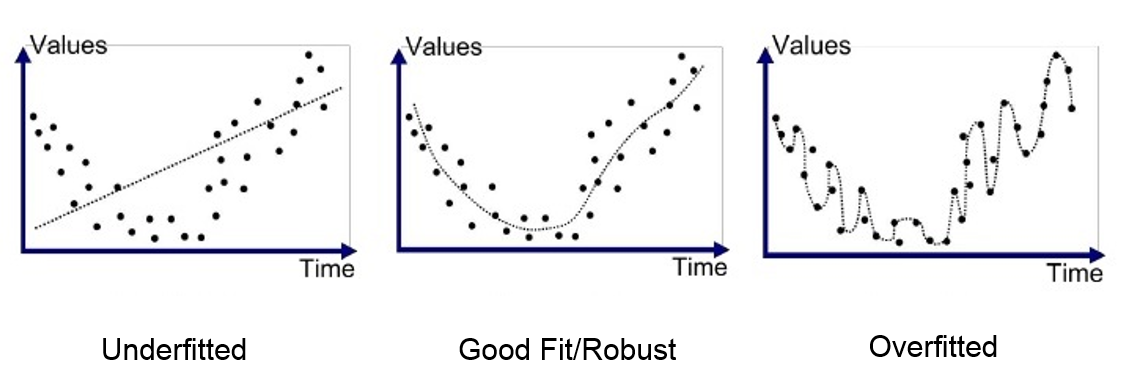

In [29]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

results = []
# Testujemy zakres wartości od bardzo silnej do bardzo słabej regularyzacji
for c_val in [0.001, 0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=c_val, max_iter=5000)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    results.append({'Wartość C': c_val, 'Dokładność (Accuracy)': accuracy})

# Wyświetlenie wyników w formie czytelnej tabeli
df_results = pd.DataFrame(results)
display(df_results)

,Wartość C,Dokładność (Accuracy)
0,0.001,0.704918
1,0.010,0.737705
2,0.100,0.852459
3,1.000,0.836066
4,10.000,0.819672
5,100.000,0.819672


## 7. Ocena końcowa modelu: Macierz Pomyłek i Krzywa ROC

Wybieramy najlepszy model z eksperymentu (C=0.1) i sprawdzamy jego jakość za pomocą bardziej zaawansowanych metryk niż sama dokładność (Accuracy).

* **Macierz Pomyłek (Confusion Matrix):** pokaże nam dokładnie, ile razy model pomylił się w każdą stronę (np. ile razy uznał osobę chorą za zdrową).
* **Krzywa ROC:** wizualizuje zdolność modelu do odróżniania klas. Pole pod krzywą (AUC) bliskie 1.0 świadczy o bardzo wysokiej jakości klasyfikatora.

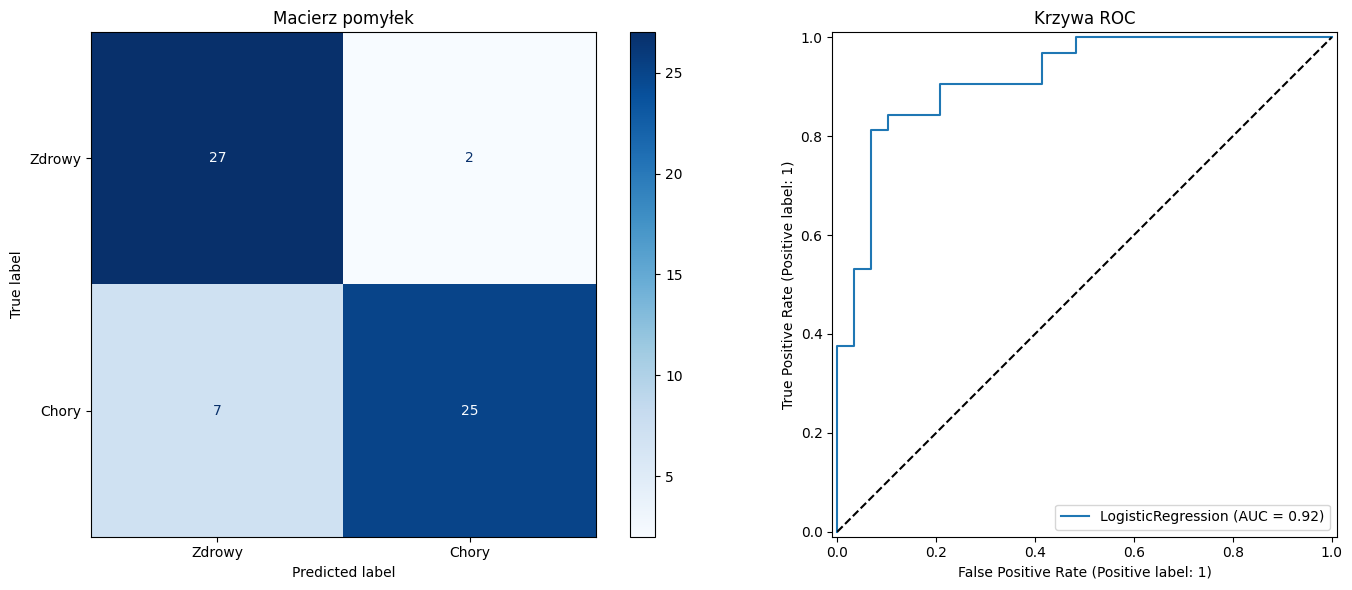

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Trenujemy model z najlepszym parametrem C=0.1
final_model = LogisticRegression(C=0.1, max_iter=5000)
final_model.fit(X_train, y_train)

# Tworzymy wykresy obok siebie
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Macierz pomyłek
cm = confusion_matrix(y_test, final_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zdrowy', 'Chory'])
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("Macierz pomyłek")

# 2. Krzywa ROC
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=ax[1])
ax[1].plot([0, 1], [0, 1], 'k--') # Linia odniesienia
ax[1].set_title("Krzywa ROC")

plt.tight_layout()
plt.show()

## 8. Podsumowanie i wnioski końcowe

1. **Efektywność modelu:** Model Regresji Logistycznej osiągnął najwyższą dokładność na poziomie ok. 85% dla parametru C=0.1.
2. **Wpływ regularyzacji:** Eksperyment potwierdził, że zbyt słaba regularyzacja (wysokie C) prowadzi do lekkiego przeuczenia modelu, co objawia się spadkiem dokładności na zbiorze testowym.
3. **Analiza błędów:** Macierz pomyłek pozwala ocenić, czy model częściej generuje błędy typu "fałszywie pozytywne" (zdrowy uznany za chorego), czy "fałszywie negatywne" (chory uznany za zdrowego). W medycynie te drugie są zazwyczaj bardziej kosztowne.
4. **Jakość separacji:** Wysoka wartość AUC (Area Under Curve) na wykresie ROC potwierdza, że model bardzo dobrze radzi sobie z rozróżnianiem pacjentów wymagających dalszej diagnostyki kardiologicznej.